# LACT 单事件完整可视化与 Hillas 重建（无 NSB）

本 notebook 沿用 LACT_sim 标准 notebook 的完整顺序：读取事件、阵列图、原始相机图、
图像清理与 Hillas 参数、方向/芯位重建、重建后相机图和 3D SDP。
两种模式只有 Cell 1 的 NSB 参数不同。


In [1]:
# Cell 1：所有需要修改的输入和分析参数都集中在这里。
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/pylast_mplcache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

INPUT_KIND = "lact_root"
INPUT_FILE = Path('/tmp/lact_notebook_no_nsb_all.root')
EVENT_ID = 1417
EVENT_INDEX = 0
MAX_EVENTS = -1

PICTURE_THRESHOLD_PE = 10.0
BOUNDARY_THRESHOLD_PE = 5.0
MIN_PICTURE_NEIGHBORS = 2
TRIGGER_THRESHOLD_PE = 8.0
TRIGGER_PIXELS = 3
IMAGE_QUERY = "hillas_intensity > 100 && leakage_intensity_width_2 < 0.3"
POISSON_MEAN_PE = 0.0

RAW_IMAGE_LEVEL = 'simulation'
CLEAN_IMAGE_LEVEL = "simulation_fake_clean"

print("mode:", '无 NSB')
print("input kind:", INPUT_KIND)
print("input file:", INPUT_FILE)
print("exists:", INPUT_FILE.exists())


mode: 无 NSB
input kind: lact_root
input file: /tmp/lact_notebook_no_nsb_all.root
exists: True


In [2]:
import json
import time
import numpy as np

try:
    import plotly.io as pio
    pio.renderers.default = "notebook_connected"
except Exception:
    pio = None

from pylast.io import LactEventSource, SimtelEventSource, RootEventSource
from pylast.calib import Calibrator
from pylast.image import ImageProcessor
from pylast.reco import ShowerProcessor
from pylast.visualize import (
    EventVisualizer,
    hillas_parameter_rows,
    plot_clean_images,
    plot_event_cameras,
    plot_gathered_images,
    plot_event_cores,
    plot_event_trigger_timing,
    plot_event_sdp_planes,
    plot_event_sdp_planes_3d,
    plot_event_sdp_planes_3d_interactive,
    plot_raw_images,
    reconstruction_summary,
)

CALIBRATOR_CONFIG = {
    "Calibrator": {
        "image_extractor_type": "LocalPeakExtractor",
        "LocalPeakExtractor": {
            "window_width": 7,
            "window_shift": 3,
            "apply_correction": False,
        },
    }
}
IMAGE_PROCESSOR_CONFIG = {
    "poisson_noise": POISSON_MEAN_PE,
    "trigger_pe": TRIGGER_THRESHOLD_PE,
    "trigger_pixels": TRIGGER_PIXELS,
    "image_cleaner_type": "Tailcuts_cleaner",
    "Tailcuts_cleaner": {
        "picture_thresh": PICTURE_THRESHOLD_PE,
        "boundary_thresh": BOUNDARY_THRESHOLD_PE,
        "keep_isolated_pixels": False,
        "min_number_picture_neighbors": MIN_PICTURE_NEIGHBORS,
    },
}
SHOWER_PROCESS_CONFIG = {
    "ShowerProcessor": {
        "GeometryReconstructionTypes": ["HillasReconstructor"],
        "HillasReconstructor": {
            "use_fake_hillas": True,
            "ImageQuery": IMAGE_QUERY,
        },
    }
}


def step(name, function):
    print(f"BEGIN {name}", flush=True)
    start = time.perf_counter()
    result = function()
    print(f"END {name}: {time.perf_counter() - start:.3f}s", flush=True)
    return result


def read_one_event(kind, filename, event_id=None, event_index=0, max_events=-1):
    filename = str(filename)
    if kind == "lact_root":
        source_data = LactEventSource(filename, max_events=max_events)
        if event_id is None:
            event = source_data[event_index]
        else:
            event = next(
                source_data[index]
                for index in range(len(source_data))
                if int(source_data[index].event_id) == int(event_id)
            )
    elif kind == "simtel":
        source_data = SimtelEventSource(filename, max_events=max(max_events, event_index + 1))
        event = list(source_data)[event_index]
    elif kind == "root_event":
        source_data = RootEventSource(filename, max_events=max_events)
        event = source_data[event_index]
    else:
        raise ValueError("INPUT_KIND must be lact_root, simtel, or root_event")
    return source_data, event, EventVisualizer(source_data)


def build_processors(source_data):
    calibrator = Calibrator(source_data.subarray, json.dumps(CALIBRATOR_CONFIG))
    image_processor = ImageProcessor(source_data.subarray, json.dumps(IMAGE_PROCESSOR_CONFIG))
    shower_processor = ShowerProcessor(source_data.subarray, json.dumps(SHOWER_PROCESS_CONFIG))
    return calibrator, image_processor, shower_processor


def prepare_raw_image(event, calibrator):
    if getattr(event, "dl0", None) is None:
        step("提取 raw image", lambda: calibrator(event))


def print_event_summary(event):
    shower = event.simulation.shower
    print("event_id:", event.event_id)
    print("run_id:", event.run_id)
    print("energy [TeV]:", float(shower.energy))
    print("true zenith [deg]:", 90.0 - np.degrees(float(shower.alt)))
    print("true azimuth [deg]:", np.degrees(float(shower.az)))
    print("true core [m]:", float(shower.core_x), float(shower.core_y))


## 1. 读取事件


In [3]:
source_data, event, visualizer = step(
    "读取事件",
    lambda: read_one_event(INPUT_KIND, INPUT_FILE, EVENT_ID, EVENT_INDEX, MAX_EVENTS),
)
calibrator, image_processor, shower_processor = build_processors(source_data)
print("subarray telescopes:", len(source_data.subarray.tels))


BEGIN 读取事件


END 读取事件: 1.866s


subarray telescopes: 32
image_cleaner_type: Tailcuts_cleaner
[2026-08-12 08:53:58.154] [info] Checking if geometry reconstruction type HillasReconstructor is registered


In [4]:
# 检查 LACT ROOT 里是否写入并能读出 ground 粒子数。
if hasattr(source_data, "get_ground_counts"):
    print("source.get_ground_counts(event):", source_data.get_ground_counts(event))
else:
    print("当前 source 没有 get_ground_counts 接口；这通常表示不是 LACT ROOT 输入。")

try:
    import ROOT
    root_path = getattr(source_data, "_input_filename", None)
    if root_path is None:
        print("没有 ROOT 输入文件路径，跳过 ROOT branch 检查。")
    else:
        f = ROOT.TFile.Open(str(root_path))
        t = f.Get("corsika_events") if f else None
        names = ["ground_gammas", "ground_electrons", "ground_hadrons", "ground_muons"]
        print("corsika_events exists:", bool(t))
        print("ground branches:", {name: bool(t and t.GetBranch(name)) for name in names})
        if t and t.GetEntries() > 0:
            target_event_id = int(getattr(event, "event_id", -1))
            for i in range(t.GetEntries()):
                t.GetEntry(i)
                if int(t.event_id) == target_event_id:
                    print("corsika_events row:", {name: getattr(t, name) for name in names})
                    break
        if f:
            f.Close()
except Exception as exc:
    print("ROOT branch 检查失败:", repr(exc))


source.get_ground_counts(event): {}
ROOT branch 检查失败: ModuleNotFoundError("No module named 'ROOT'")


In [5]:
prepare_raw_image(event, calibrator)
print_event_summary(event)

# ImageProcessor 同时生成 simulation.fake_image、清理掩膜和 Hillas 参数。
step("图像处理 + Hillas 参数", lambda: image_processor(event))
print("Poisson NSB mean [PE/pixel]:", POISSON_MEAN_PE)


event_id: 1417
run_id: 0
energy [TeV]: 2.9431171875
true zenith [deg]: 21.785725055928992
true azimuth [deg]: 4.797383260277221
true core [m]: 1.2572239685058595 641.64578125
BEGIN 图像处理 + Hillas 参数


END 图像处理 + Hillas 参数: 0.001s


Poisson NSB mean [PE/pixel]: 0.0


In [6]:
# 重新选择事件时，只需修改 Cell 1 后从这里以上重新运行。
# source_data, event, visualizer = read_one_event(
#     INPUT_KIND, INPUT_FILE, EVENT_ID, EVENT_INDEX, MAX_EVENTS
# )
# calibrator, image_processor, shower_processor = build_processors(source_data)
# prepare_raw_image(event, calibrator)
# image_processor(event)


## 2. 望远镜分布、触发时间、芯位与 SDP 投影

保持 LACT_sim 标准 notebook 的阵列级检查。pyLAST 后加的积分 NSB 没有独立时间轴，
所以触发时间图仍读取 LACT_sim ROOT 中原始保存的触发时间。


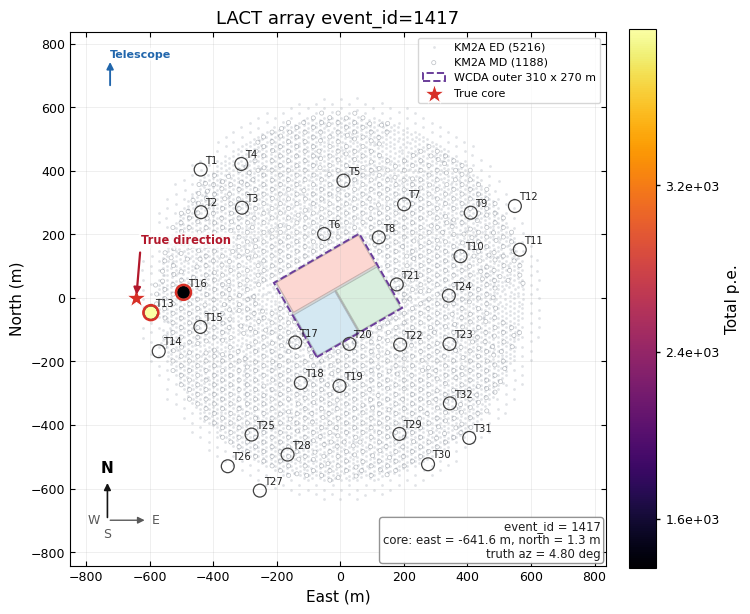

In [7]:
core_result = plot_event_cores(
    event,
    visualizer=visualizer,
    image_level=RAW_IMAGE_LEVEL,
    include_non_triggered=False,
)


In [8]:
# 颜色表示总 p.e.；标签同时给出原始触发延迟、由望远镜位置计算的物理延迟，
# 以及扣除物理延迟后的修正时间。阵列背景、core 和入射方向沿用 plot_event_cores。
trigger_timing = (
    source_data.get_trigger_timing(event)
    if hasattr(source_data, "get_trigger_timing") else {}
)
if trigger_timing:
    plot_event_trigger_timing(
        event,
        visualizer=visualizer,
        image_level="dl0",
        annotate=True,
        wavefront_speed_m_per_ns=0.29974,
    )
else:
    print("当前输入没有望远镜触发时间；请使用新版 LACT ROOT 输出。")


当前输入没有望远镜触发时间；请使用新版 LACT ROOT 输出。


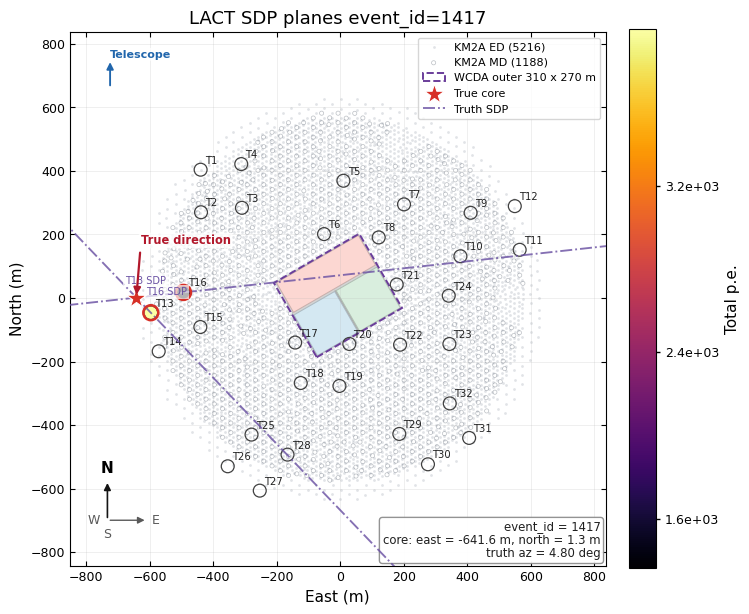

In [9]:
sdp_result = plot_event_sdp_planes(
    event,
    visualizer=visualizer,
    image_level=RAW_IMAGE_LEVEL,
    include_non_triggered=False,
)


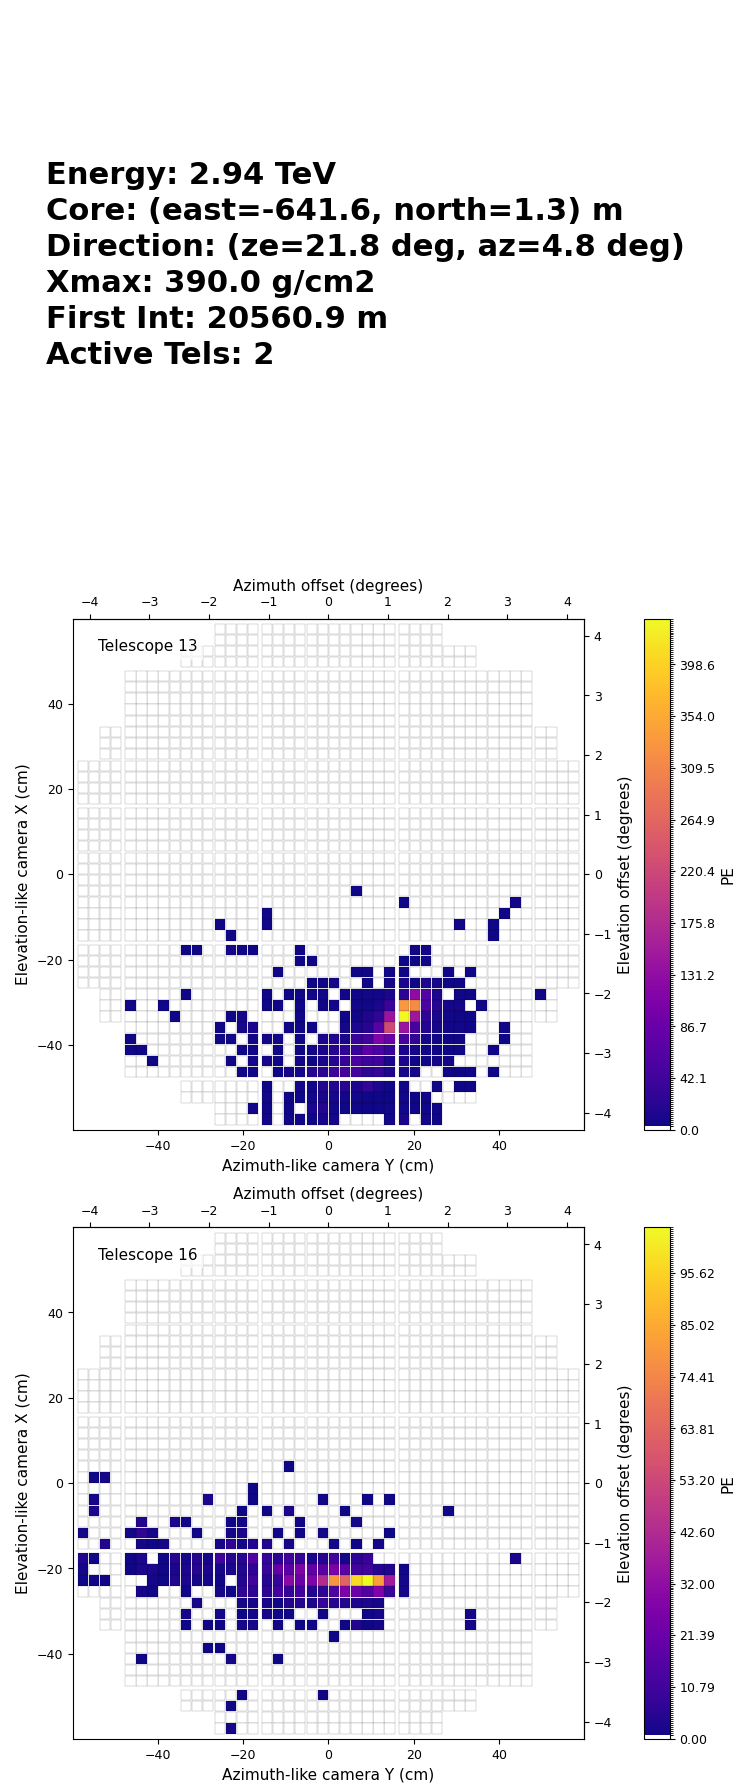

In [10]:
# 与 LACT_sim 标准 notebook 一样，直接使用 pyLAST 原生 EventVisualizer。
_ = plot_event_cameras(
    event,
    visualizer=visualizer,
    image_level="simulation",
    include_non_triggered=False,
)


## 3. Raw image（无 NSB）

这里画清理前的 `simulation`。有 NSB 模式已经加入泊松 NSB，并减去平均基线；
无 NSB 模式直接显示纯切伦科夫 `simulation.true_image`。


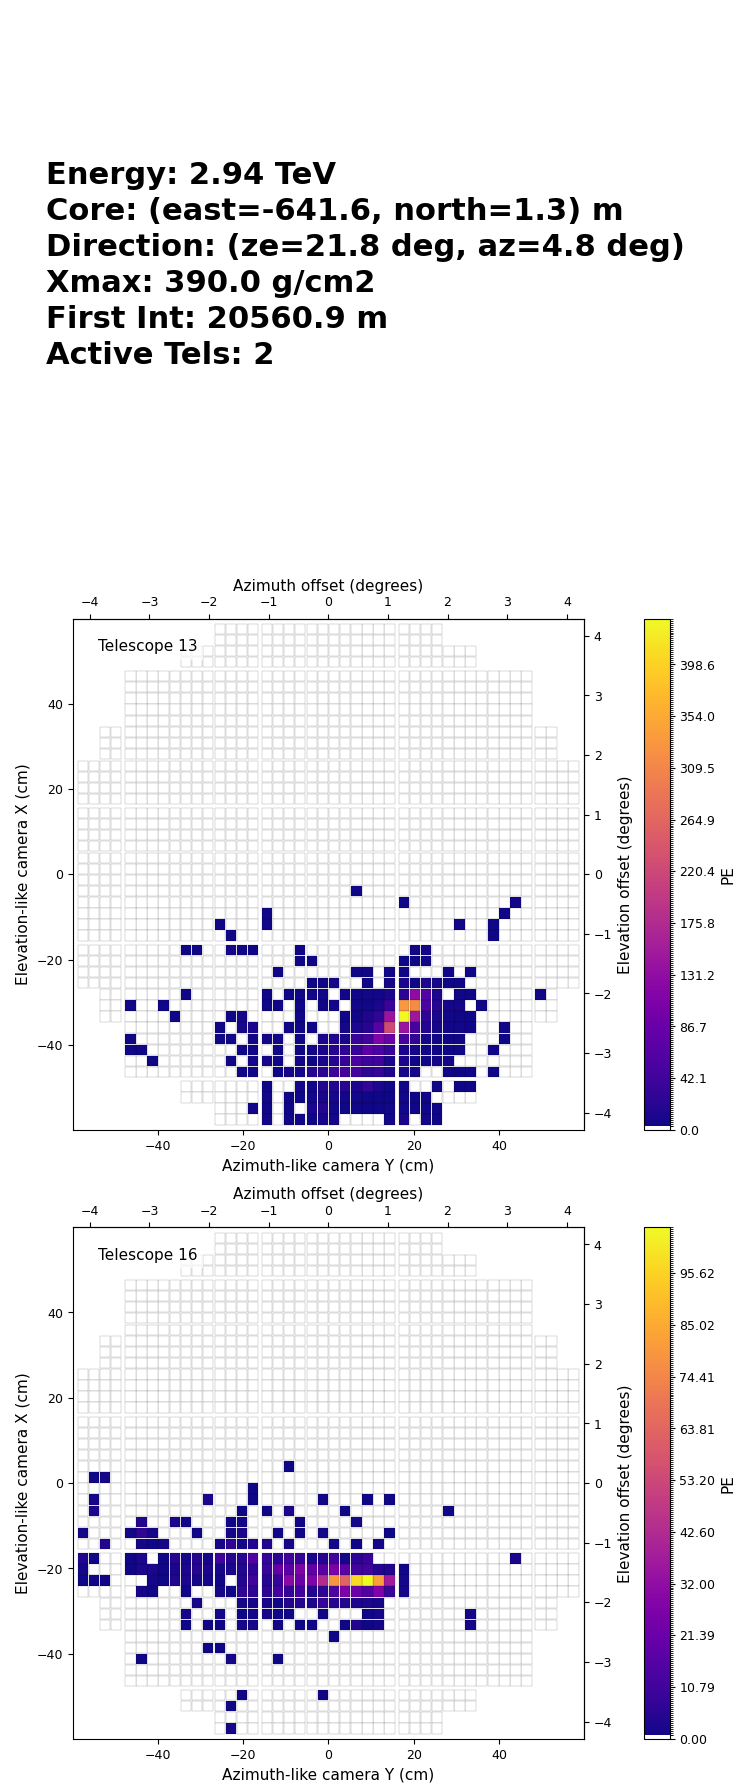

In [11]:
raw_result = plot_raw_images(
    event,
    visualizer=visualizer,
    image_level=RAW_IMAGE_LEVEL,
    include_non_triggered=False,
)


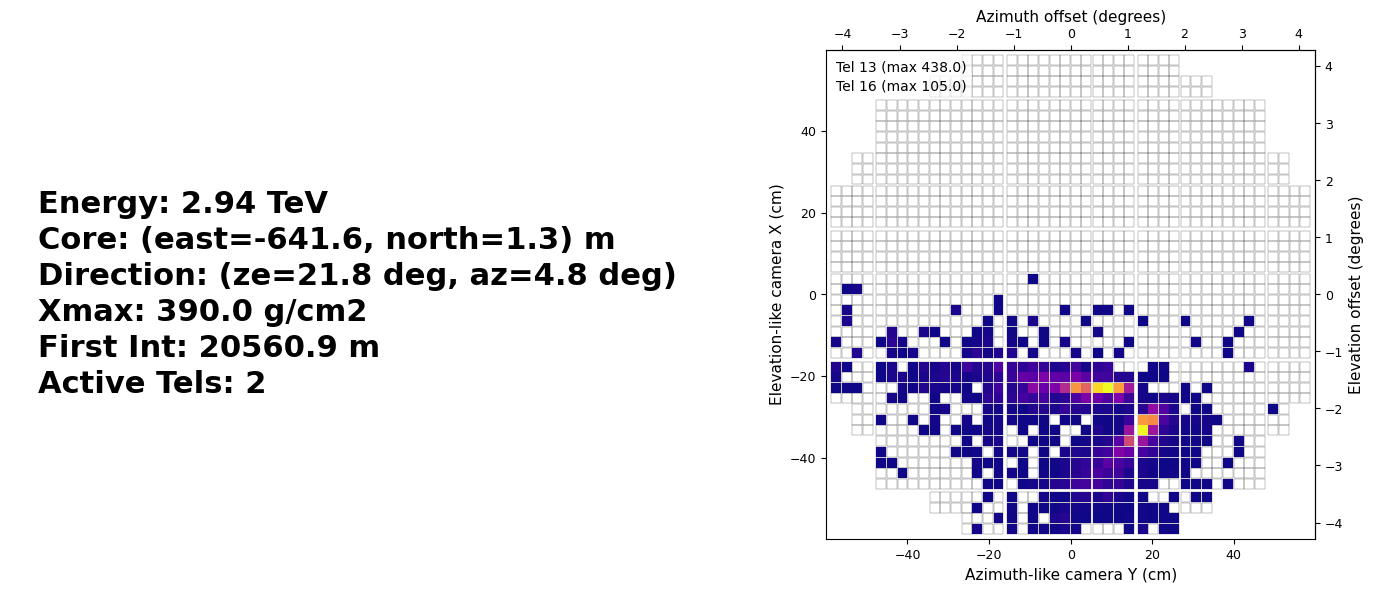

In [12]:
_ = plot_gathered_images(
    event,
    visualizer=visualizer,
    image_type=None,
    image_level=RAW_IMAGE_LEVEL,
    show_hillas=False,
    include_non_triggered=False,
)


## 4. Clean image 与 Hillas 参数

显示同一次 `ImageProcessor` 产生的清理掩膜、清理后图像和 Hillas 椭圆。


In [13]:
rows = hillas_parameter_rows(event, image_level=CLEAN_IMAGE_LEVEL)
print("有 Hillas 参数的望远镜:", [row["tel_id"] for row in rows])
for row in rows:
    print(
        f"Tel {row['tel_id']:2d}: intensity={row['intensity']:.2f}, "
        f"length={row['length_rad']:.5g} rad, width={row['width_rad']:.5g} rad, "
        f"psi={np.degrees(row['psi_rad']):.2f} deg"
    )


有 Hillas 参数的望远镜: [12, 15]
Tel 12: intensity=3576.00, length=0.0098831 rad, width=0.003357 rad, psi=47.45 deg
Tel 15: intensity=1011.00, length=0.0095794 rad, width=0.0024811 rad, psi=-85.61 deg


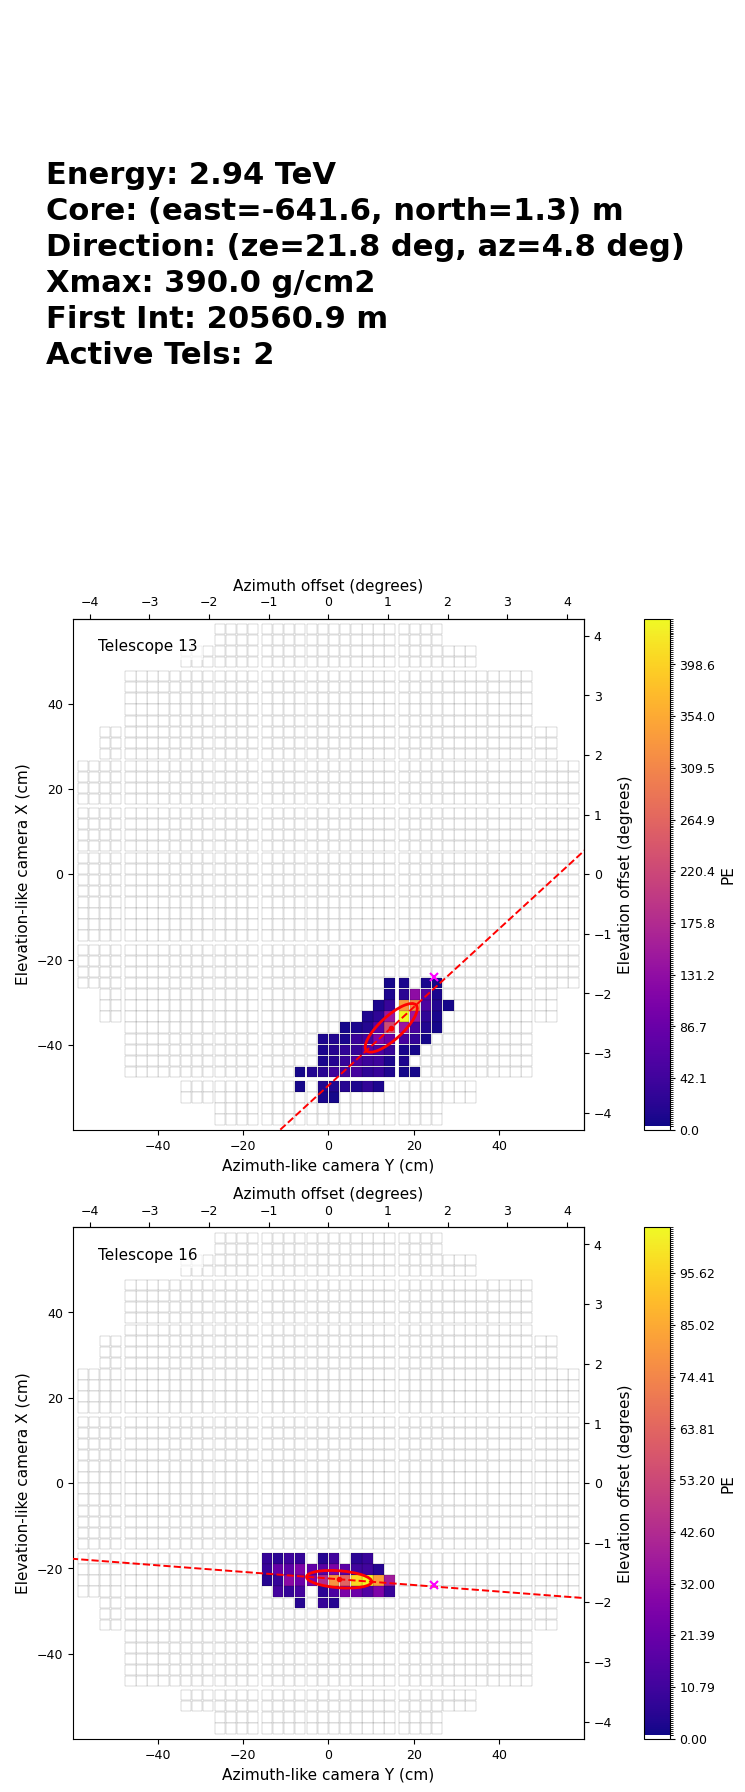

In [14]:
clean_result = plot_clean_images(
    event,
    visualizer=visualizer,
    image_level=CLEAN_IMAGE_LEVEL,
    show_hillas=True,
    include_non_triggered=False,
    ideal=True,
)


## 5. 方向与芯位重建


In [15]:
step("方向/芯位重建", lambda: shower_processor(event))
summary = reconstruction_summary(event, "HillasReconstructor")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6g}")
    else:
        print(f"{key}: {value}")
assert summary["is_valid"], "该事件没有得到有效 Hillas 立体重建"


BEGIN 方向/芯位重建


END 方向/芯位重建: 0.000s


event_id: 1417
reconstructor: HillasReconstructor
is_valid: True
n_hillas_telescopes: 2
hillas_telescope_ids: [12, 15]
true_alt_deg: 68.2143
true_az_deg: 4.79738
true_zenith_deg: 21.7857
true_core_x_m: 1.25722
true_core_y_m: 641.646
reco_alt_deg: 68.1661
reco_az_deg: 5.258
reco_zenith_deg: 21.8339
reco_core_x_m: 3.38736
reco_core_y_m: 648.371
direction_error_deg: 0.177773
truth_reco_sep_deg: 0.177773


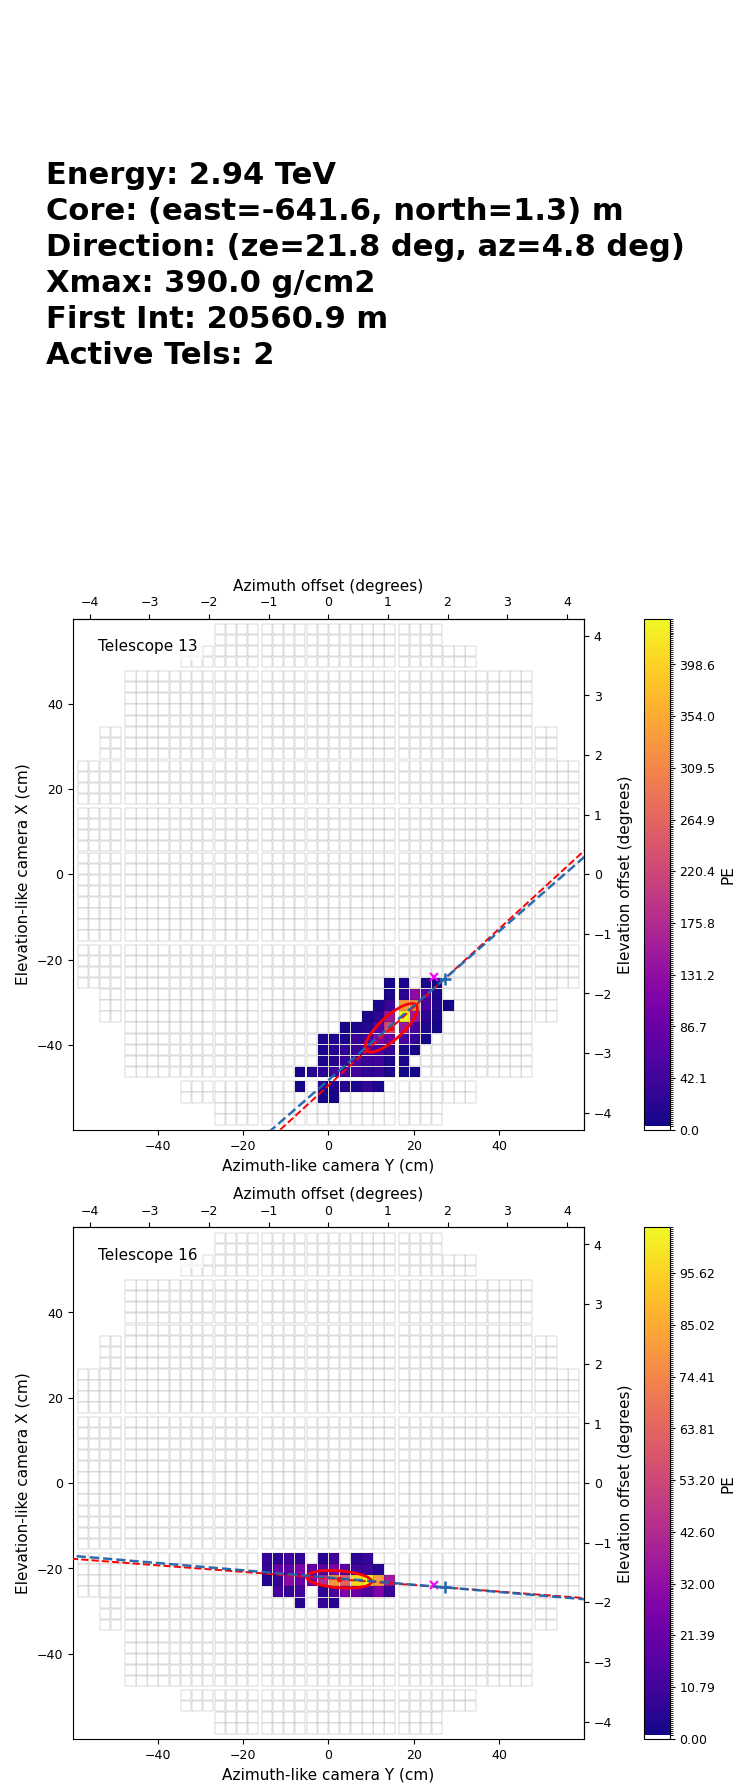

In [16]:
_ = plot_clean_images(
    event,
    visualizer=visualizer,
    image_level=CLEAN_IMAGE_LEVEL,
    show_hillas=True,
    include_non_triggered=False,
    ideal=True,
    reco=True,
)


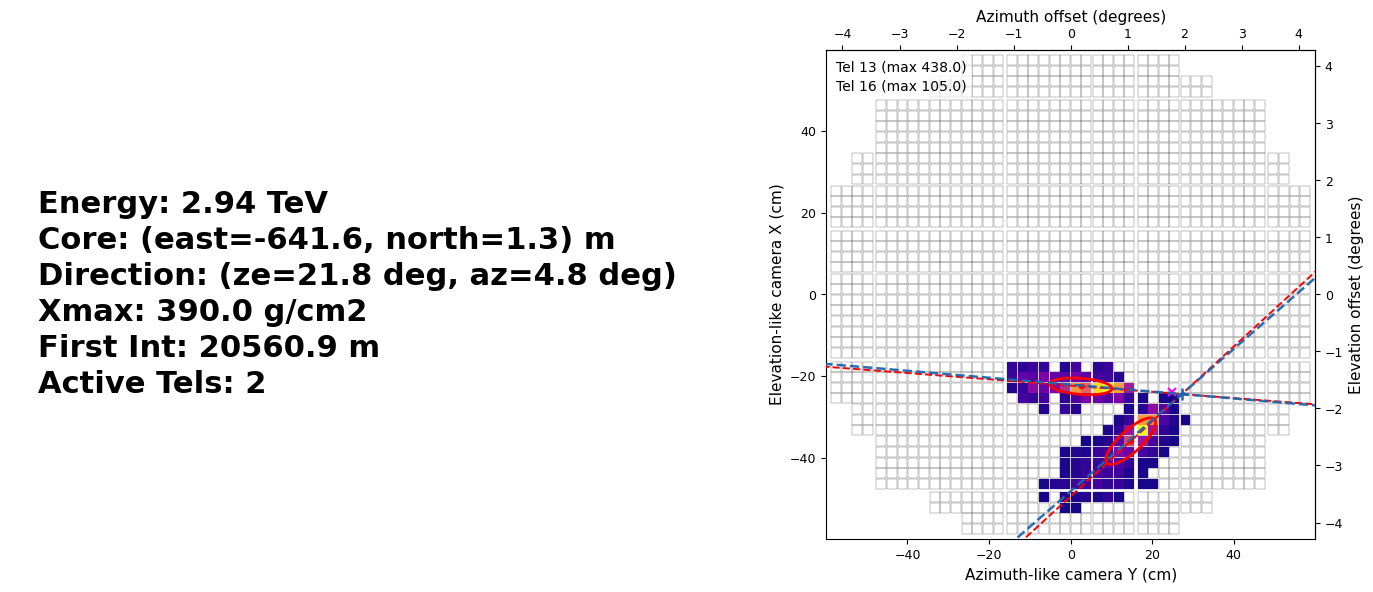

In [17]:
_ = plot_gathered_images(
    event,
    visualizer=visualizer,
    image_type=None,
    image_level=CLEAN_IMAGE_LEVEL,
    show_hillas=True,
    include_non_triggered=False,
    ideal=True,
    reco=True,
)


## 6. 3D SDP 平面


In [18]:
sdp_3d_interactive_figure = None
if pio is None:
    print("未安装 Plotly，跳过交互式 3D SDP；下一 Cell 仍会绘制静态版本。")
else:
    sdp_3d_interactive_figure = plot_event_sdp_planes_3d_interactive(
        event,
        visualizer=visualizer,
        image_level=CLEAN_IMAGE_LEVEL,
        include_non_triggered=False,
        z_max=1200.0,
        show_reco=True,
    )
    sdp_3d_interactive_figure


未安装 Plotly，跳过交互式 3D SDP；下一 Cell 仍会绘制静态版本。


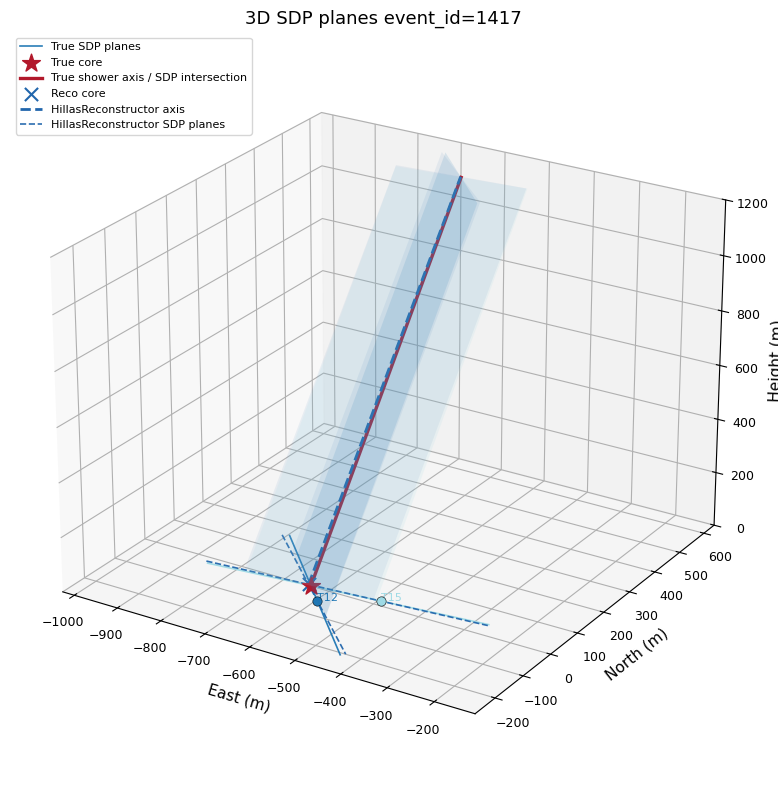

In [19]:
sdp_3d_result = plot_event_sdp_planes_3d(
    event,
    visualizer=visualizer,
    image_level=CLEAN_IMAGE_LEVEL,
    include_non_triggered=False,
    z_max=1200.0,
    show_reco=True,
    show=True,
)


## 7. 可选：保存图片


In [20]:
# OUTPUT_DIR = Path(INPUT_FILE).parent / "pylast_visualize"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# for name, result in {
#     "core": core_result,
#     "sdp": sdp_result,
#     "raw": raw_result,
#     "clean": clean_result,
#     "sdp_3d": sdp_3d_result,
# }.items():
#     figure = result.get("figure")
#     if figure is not None:
#         figure.savefig(
#             OUTPUT_DIR / f"event_{event.event_id}_{name}.png",
#             dpi=200,
#             bbox_inches="tight",
#         )
# if sdp_3d_interactive_figure is not None:
#     sdp_3d_interactive_figure.write_html(
#         OUTPUT_DIR / f"event_{event.event_id}_sdp_3d_interactive.html",
#         include_plotlyjs="cdn",
#         full_html=True,
#     )


## 项目位置

这两本 notebook 在 LACT_sim 和 pyLAST 的 `notebooks/` 中保持完全相同。
修改 Cell 1 的 `INPUT_FILE` 和 `EVENT_ID` 后即可用于其他 LACT ROOT 文件。
